## Football Match Dashboard

In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from statsbombpy import sb
from mplsoccer import VerticalPitch
# pd.set_option('display.max_rows', None)

Statsbomb Py

In [2]:
sb.competitions()

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,NaN,NaN,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,NaN,NaN,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,NaN,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,NaN,2024-02-13T02:35:28.134882
...,...,...,...,...,...,...,...,...,...,...,...,...
70,35,75,Europe,UEFA Europa League,male,False,False,1988/1989,2024-02-12T14:45:05.702250,2021-06-13T16:17:31.694,NaN,2024-02-12T14:45:05.702250
71,53,315,Europe,UEFA Women's Euro,female,False,True,2025,2025-07-28T14:19:20.467348,2025-07-29T16:03:07.355174,2025-07-29T16:03:07.355174,2025-07-28T14:19:20.467348
72,53,106,Europe,UEFA Women's Euro,female,False,True,2022,2024-02-13T13:27:17.178263,2024-02-13T13:30:52.820588,2024-02-13T13:30:52.820588,2024-02-13T13:27:17.178263
73,72,107,International,Women's World Cup,female,False,True,2023,2025-07-14T10:07:06.620906,2025-07-14T10:10:27.224586,2025-07-14T10:10:27.224586,2025-07-14T10:07:06.620906


In [3]:
sb.matches(competition_id=16, season_id=39)

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3750200,2007-05-23,20:45:00.000,Europe - Champions League,2006/2007,AC Milan,Liverpool,2,1,available,...,2021-06-13T16:17:31.694,1,Final,Olympiako Stadio Spyros Louis,Herbert Fandel,Carlo Ancelotti,Rafael Benítez Maudes,1.1.0,2,2


Data Preparation

In [4]:
df = sb.events(match_id=3750200).sort_values(by=['index'])

In [5]:
df.head()

,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_offensive,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 4321, 'lineup': [{'player': {'id...",AC Milan,243,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",Liverpool,24,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Liverpool,24,00:00:00.000,Half Start,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,AC Milan,243,00:00:00.000,Half Start,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Liverpool,24,00:00:00.399,Pass,NaN


In [6]:
df.columns

Index(['50_50', 'ball_receipt_outcome', 'ball_recovery_recovery_failure',
       'block_offensive', 'carry_end_location', 'clearance_aerial_won',
       'clearance_body_part', 'clearance_head', 'clearance_left_foot',
       'clearance_right_foot', 'counterpress', 'dribble_nutmeg',
       'dribble_outcome', 'dribble_overrun', 'duel_outcome', 'duel_type',
       'duration', 'foul_committed_advantage', 'foul_committed_card',
       'foul_committed_offensive', 'foul_committed_type', 'foul_won_advantage',
       'foul_won_defensive', 'goalkeeper_body_part', 'goalkeeper_end_location',
       'goalkeeper_outcome', 'goalkeeper_position', 'goalkeeper_technique',
       'goalkeeper_type', 'id', 'index', 'interception_outcome', 'location',
       'match_id', 'minute', 'miscontrol_aerial_won', 'off_camera', 'out',
       'pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id',
       'pass_body_part', 'pass_cross', 'pass_cut_back', 'pass_end_location',
       'pass_goal_assist', 'pass_height', 'p

In [ ]:
df.to_csv('./data/acmilan_liverpool_UCL_20070523.csv', index=False)

In [8]:
# Split the data into two teams
team1 = df[df.team == 'AC Milan']
team2 = df[df.team == 'Liverpool']

In [9]:
# Set a couple of constants for the colors
ACMILAN_COLOR = "#EEE2E2FF"
ACMILAN_TEAM_ID = 243
LIVERPOOL_COLOR = "#c8102e"
LIVERPOOL_TEAM_ID = 24

Dashboard Functions

In [10]:
def create_shotmap(team, ax):
    pitch = VerticalPitch(pitch_type='statsbomb', half=True)
    pitch.draw(ax=ax)
    
    # the shots data is in the 'type' column
    team = team[team['type']=='Shot']
    
    # Filter the data to only include the relevant columns and split the location into x and y
    team = team[['team', 'player', 'location', 'shot_outcome', 'shot_statsbomb_xg', 'shot_type']]
    team[['x', 'y']] = team['location'].apply(pd.Series)
    
    # Draw the shotmap
    for x in team.to_dict(orient='records'):
    
        pitch.scatter(
            x=x['x'], y=x['y'], ax=ax, 
            s=500 * x['shot_statsbomb_xg'], 
            color='green' if x['shot_outcome'] == 'Goal' else 'white', 
            edgecolors='black', alpha=0.7
        )

In [11]:
def create_passnetwork(team, ax):
    team[['x', 'y']] = team['location'].apply(pd.Series)
    
    tactics = team[~team['tactics'].isnull()][['tactics', 'team']]

    all_jersey_numbers = []
    for y in tactics.to_dict(orient='records'):
        all_jersey_numbers.append(pd.DataFrame([{'player_id': x['player']['id'], 'jersey_number': x['jersey_number']} for x in y['tactics']['lineup']]))
        
    jersey_numbers = pd.concat(all_jersey_numbers).drop_duplicates()
    
    # Make a new, single column for time and sort the events in chronological order
    team["newsecond"] = 60 * team["minute"] + team["second"]
    
    team.sort_values(by=['newsecond'])
    
    # Identify the passer and then the recipient, who'll be the playerId of the next action
    team['passer'] = team['player_id']
    
    team['recipient'] = team['passer'].shift(-1)
    
    # Filter for only passes and then successful passes
    passes_df = team.loc[(team['type']=="Pass")]
    passes_df['pass_outcome'] = passes_df['pass_outcome'].fillna("Successful")
    
    completions = passes_df.loc[(passes_df['pass_outcome'] == "Successful")]
    
    # Find time of the team's first substitution and filter the df to only passes before that
    sub_df = team.loc[(team['type'] == "Substitution")]
    first_sub = sub_df["newsecond"].min()
    
    if first_sub <= (60 * 45):
        first_sub = 60 * 45
    
    completions = completions.loc[completions['newsecond'] < first_sub]
    
    # Find average locations
    average_locs_and_count = completions.groupby('passer').agg({'x': ['mean'], 'y': ['mean','count']})
    average_locs_and_count.columns = ['x', 'y', 'count']
    
    # Find number of passes along each 'path' of passer to recipient
    passes_between = completions.groupby(['passer', 'recipient']).id.count().reset_index()
    passes_between.rename({'id': 'pass_count'}, axis='columns', inplace=True)
    
    passes_between = passes_between.merge(average_locs_and_count, left_on='passer', right_index=True)
    passes_between = passes_between.merge(
        average_locs_and_count, left_on='recipient', right_index=True, suffixes=['', '_end']
    )
    
    # Set minimum threshold for pass arrows to be plotted, so this will only plot combos which occured at least 5 times
    passes_between = passes_between.loc[(passes_between['pass_count'] >= 4)]
    
    # Plot arrows
    def pass_line_template(ax, x, y, end_x, end_y, line_color):
        ax.annotate(
            '',
            xy=(end_y,  end_x),
            xytext=(y, x),
            zorder=1,
            arrowprops=dict(arrowstyle='-|>', linewidth=4, color=line_color, alpha=.85)
        )
        
    def pass_line_template_shrink(ax, x, y, end_x, end_y, line_color, dist_delta=1.2):
        dist = math.hypot(end_x - x, end_y - y)
        angle = math.atan2(end_y-y, end_x-x)
        upd_x = x + (dist - dist_delta) * math.cos(angle)
        upd_y = y + (dist - dist_delta) * math.sin(angle)
        pass_line_template(ax, x, y, upd_x, upd_y, line_color=line_color)
    
    pitch = VerticalPitch(pitch_type='statsbomb')
    pitch.draw(ax=ax)
    
    for index, row in passes_between.iterrows():
        pass_line_template_shrink(ax, row['x'], row['y'], row['x_end'], row['y_end'], 'black')
    
    # Plot nodes
    pitch.scatter(
        average_locs_and_count.x, average_locs_and_count.y, s=500,
        color='#f0ece2', edgecolors="#010101", linewidth=2, alpha=1, ax=ax, zorder=2
    )
    
    for index, row in average_locs_and_count.iterrows():
        pitch.annotate(
            jersey_numbers[jersey_numbers['player_id'] == row.name]['jersey_number'].values[0],
            xy=(row.x, row.y),
            c='#132743',
            va='center',
            ha='center',
            size=10,
            fontweight='bold',
            ax=ax
        )

In [12]:
def create_table(team1, team2):
    # Drop rows where the pass_outcome is Unknown
    team1 = team1[team1['pass_outcome'] != 'Unknown']
    team2 = team2[team2['pass_outcome'] != 'Unknown']
    
    # Create a table with the data
    # We first need to calculate the statistics for each team
    # we will calcualte the following stats:
    # - goals
    # - xG
    # - shots
    # - shots on target
    # - passes
    # - pass completion %
    
    # Create a dictionary to store the stats
    stats = {
        'goals': {
            'team1': len(team1[team1['type'] == 'Goal']), 'team2': len(team2[team2['type'] == 'Goal'])
            },
        'xG': {
            'team1': round(team1['shot_statsbomb_xg'].sum(), 2), 'team2': round(team2['shot_statsbomb_xg'].sum(), 2)
            },
        'shots': {
            'team1': len(team1[team1['type'] == 'Shot']), 'team2': len(team2[team2['type'] == 'Shot'])
            },
        'shots_on_target': {
            'team1': len(team1[(team1['type'] == 'Shot') & (team1['shot_end_location'].str.len() > 2) & (team1['shot_outcome'] != 'Off T')]), 
            'team2': len(team2[(team2['type'] == 'Shot') & (team2['shot_end_location'].str.len() > 2) & (team2['shot_outcome'] != 'Off T')])
        },
        'passes': {
            'team1': len(team1[team1['type'] == 'Pass']), 'team2': len(team2[team2['type'] == 'Pass'])
            },
        'pass_completion': {
            'team1': round(len(team1[(team1['type'] == 'Pass') & (team1['pass_outcome'].isna())]) / len(team1[team1['type'] == 'Pass']) * 100, 2) ,
            'team2': round(len(team2[(team2['type'] == 'Pass') & (team2['pass_outcome'].isna())]) / len(team2[team2['type'] == 'Pass']) * 100, 2)
        }
    }
    
    # Store as a dataframe
    stats_df = pd.DataFrame(stats).T

    column_labels = ['', '', '']
    table_vals = [
        [str(stats_df['team1']['xG']), 'xG', str(stats_df['team2']['xG'])],
        [str(int(stats_df['team1']['shots'])), 'Shots', str(int(stats_df['team2']['shots']))],
        [str(int(stats_df['team1']['shots_on_target'])), 'Shots on Target', str(int(stats_df['team2']['shots_on_target']))],
        [str(int(stats_df['team1']['passes'])), 'Passes', str(int(stats_df['team2']['passes']))],
        [str(stats_df['team1']['pass_completion']), 'Pass Completion %', str(stats_df['team2']['pass_completion'])]
    ]
    
    return column_labels, table_vals

In [13]:
def create_xg_flow_chart(df, ax):
    # We'll use the original df instead of the team1 and team2 dataframes
    
    # Filter the columns to only shots
    df = df[df['type'] == 'Shot']
    
    # Sort the values so they are in order of time
    df = df.sort_values(by="index")
    
    # Calculate the cumulative xG for each team
    df['cumulative_xG'] = df.groupby('team_id')['shot_statsbomb_xg'].cumsum()
    
    # Plot the xG for each team by half
    # We want to make it so the lines both start at 0
    for team in df['team_id'].unique():
        
        team_df = df[df['team_id'] == team]
        
        # Add a 0 xG row at the start of the match
        team_df = pd.concat([pd.DataFrame({
            'team_id': team, 'minute': 0, 'shot_statsbomb_xg': 0, 'shot_outcome': None, 'cumulative_xG': 0, 'period': 1
        }, index=[0]), team_df])
        
        ax.plot(
            team_df['minute'], 
            team_df['cumulative_xG'], 
            label=team, 
            drawstyle='steps-post',
            c='black' if team == ACMILAN_TEAM_ID else LIVERPOOL_COLOR
        )   
            
    # We can add a scatter plot to show the goals
    for team in df['team_id'].unique():
        team_df = df[(df['team_id'] == team) & (df['shot_outcome'] == 'Goal')].to_dict(orient='records')
        for x in team_df:
            ax.scatter(
                x['minute'], 
                x['cumulative_xG'], 
                c='white',
                edgecolor='black' if team == ACMILAN_TEAM_ID else LIVERPOOL_COLOR,
                s=100,
                # We want the goals to be on top of the lines
                zorder=5
            )
            
            # Add a label to the goals for the player who scored
            ax.text(
                x['minute'], 
                x['cumulative_xG'] - .07, 
                x['player'], 
                ha='center', 
                va='center', 
                fontfamily='monospace', 
                fontsize=8,
                zorder=10
            )
            
    # Let's label the x axis with first and second half
    ax.set_xticks([0, 45, 90]) #, 120])
    ax.set_xticklabels(['0\'', '45\'', '90\'']) #, '120\'']) If extra time
    
    # Let's get rid of the right and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

In [14]:
team1_tactics = team1[~team1['tactics'].isnull()][['tactics', 'team']]
team1_tactics = team1_tactics.head(1) # We must extract only the first row since the lineup can change during the game and there can be more than one occurrence

team1_tactics_formation = team1_tactics['tactics'].apply(lambda x: x.get('formation') if isinstance(x, dict) else x)
print("Formation:", team1_tactics_formation.iloc[0])

team1_tactics_lineup = team1_tactics['tactics'].apply(lambda x: x.get('lineup') if isinstance(x, dict) else x)
player_list_team1 = []

# Iterate through the lineups in the series
for lineup in team1_tactics_lineup:
    if lineup:  # Check if the lineup is not empty
        # For each player in the lineup, extract the name and jersey number
        for player_info in lineup:
            player_name = player_info['player']['name']
            jersey_number = player_info['jersey_number']
            player_list_team1.append({'player_name': player_name, 'jersey_number': jersey_number})

# Print the final list
print("Lineup:", player_list_team1)

Formation: 4321
Lineup: [{'player_name': 'Nelson de Jesus da Silva', 'jersey_number': 1}, {'player_name': 'Massimo Oddo', 'jersey_number': 44}, {'player_name': 'Alessandro Nesta', 'jersey_number': 13}, {'player_name': 'Paolo Maldini', 'jersey_number': 3}, {'player_name': 'Marek Jankulovski', 'jersey_number': 18}, {'player_name': 'Andrea Pirlo', 'jersey_number': 21}, {'player_name': 'Massimo Ambrosini', 'jersey_number': 23}, {'player_name': 'Ivan Gennaro Gattuso', 'jersey_number': 8}, {'player_name': 'Ricardo Izecson dos Santos Leite', 'jersey_number': 22}, {'player_name': 'Clarence Seedorf', 'jersey_number': 10}, {'player_name': 'Filippo Inzaghi', 'jersey_number': 9}]


In [15]:
team2_tactics = team2[~team2['tactics'].isnull()][['tactics', 'team']]
team2_tactics = team2_tactics.head(1) # We must extract only the first row since the lineup can change during the game and there can be more than one occurrence

team2_tactics_formation = team2_tactics['tactics'].apply(lambda x: x.get('formation') if isinstance(x, dict) else x)
print("Formation:", team2_tactics_formation.iloc[0])

team2_tactics_lineup = team2_tactics['tactics'].apply(lambda x: x.get('lineup') if isinstance(x, dict) else x)
player_list_team2 = []

# Iterate through the lineups in the series
for lineup in team2_tactics_lineup:
    if lineup:  # Check if the lineup is not empty
        # For each player in the lineup, extract the name and jersey number
        for player_info in lineup:
            player_name = player_info['player']['name']
            jersey_number = player_info['jersey_number']
            player_list_team2.append({'player_name': player_name, 'jersey_number': jersey_number})

# Print the final list
print("Lineup:", player_list_team2)

Formation: 4231
Lineup: [{'player_name': 'José Manuel Reina Páez', 'jersey_number': 25}, {'player_name': 'Steve Finnan', 'jersey_number': 3}, {'player_name': 'Jamie Carragher', 'jersey_number': 23}, {'player_name': 'Daniel Munthe Agger', 'jersey_number': 5}, {'player_name': 'John Arne Semundseth Riise', 'jersey_number': 6}, {'player_name': 'Javier Alejandro Mascherano', 'jersey_number': 20}, {'player_name': 'Xabier Alonso Olano', 'jersey_number': 14}, {'player_name': 'Jermaine Pennant', 'jersey_number': 16}, {'player_name': 'Steven Gerrard', 'jersey_number': 8}, {'player_name': 'Boudewijn Zenden', 'jersey_number': 32}, {'player_name': 'Dirk Kuijt', 'jersey_number': 18}]


Dashboard

(np.float64(-4.0), np.float64(84.0), np.float64(56.0), np.float64(124.0))

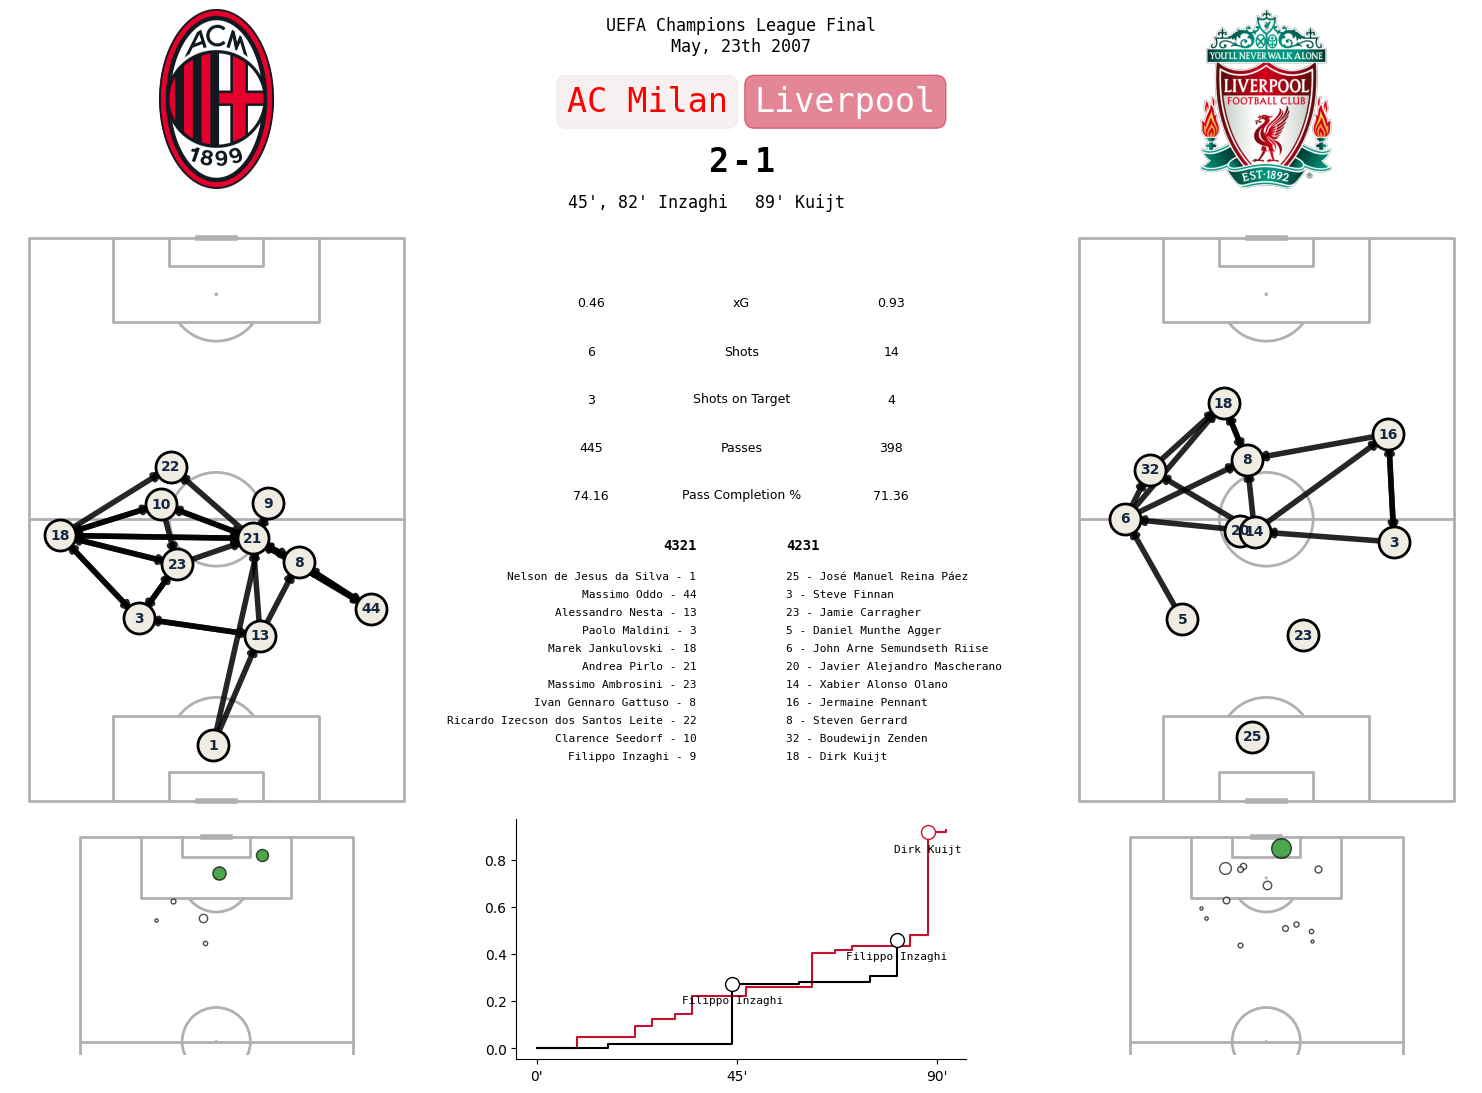

In [ ]:
# Set up the figure and grid layout
fig = plt.figure(figsize=(15, 12))

# Top row for the team names and score
# [left, bottom, width, height]

ax1 = fig.add_axes([0.225, 0.775, 0.15, 0.15])

team1_img = Image.open('./figures/acmilan.png')
ax1.imshow(team1_img)
ax1.axis('off')

ax2 = fig.add_axes([0.5, 0.8, 0.3, 0.1])
ax2.text(0.5, 0.9, 'UEFA Champions League Final\nMay, 23th 2007', fontsize=12, ha='center', fontdict={'family': 'monospace'})

team_1_text = ax2.text(0.47, .4, 'AC Milan', fontsize=24, ha='right', fontdict={'family': 'monospace'}, color='red')
team_1_text.set_bbox(dict(facecolor=ACMILAN_COLOR, alpha=0.5, edgecolor=ACMILAN_COLOR, boxstyle='round'))

team_2_text = ax2.text(0.53, .4, 'Liverpool', fontsize=24, ha='left', fontdict={'family': 'monospace'}, color='white')
team_2_text.set_bbox(dict(facecolor=LIVERPOOL_COLOR, alpha=0.5, edgecolor=LIVERPOOL_COLOR, boxstyle='round'))

ax2.text(0.47, -0.1, '2', fontsize=24, ha='right', fontdict={'family': 'monospace', 'weight': 'bold'})
ax2.text(0.5, -0.1, '-', fontsize=24, ha='center', fontdict={'family': 'monospace', 'weight': 'bold'})
ax2.text(0.53, -0.1, '1', fontsize=24, ha='left', fontdict={'family': 'monospace', 'weight': 'bold'})

ax2.text(0.47, -0.4, "45', 82' Inzaghi", fontsize=12, ha='right', fontdict={'family': 'monospace'})
#ax2.text(0.5, -0.4, "⚽", fontsize=12, ha='center', fontdict={'family': 'Segoe UI Emoji'})
ax2.text(0.53, -0.4, "89' Kuijt", fontsize=12, ha='left', fontdict={'family': 'monospace'})

ax2.axis('off')

ax3 = fig.add_axes([0.925, 0.775, 0.15, 0.15])

team2_img = Image.open('./figures/liverpool.png')
ax3.imshow(team2_img)
ax3.axis('off')

# ax4 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_axes([0.15, 0.25, 0.3, 0.5])
create_passnetwork(team1, ax4)
ax4.axis('off')

ax5 = fig.add_axes([0.5, 0.25, 0.3, 0.5])
# Create a table with data. The middle column will be the statistic with the left and right columns being the stats for each team
column_labels, table_vals = create_table(team1, team2)

table = ax5.table(
    cellText=table_vals, 
    cellLoc='center', 
    edges='vertical',
    bbox=[0, .5, 1, .4],
)

for (i, j), cell in table.get_celld().items():
    if j == 0:
        table.get_celld()[(i, j)].visible_edges = '' # L
    elif j == 2:
        table.get_celld()[(i, j)].visible_edges = '' # LR
    else:
        table.get_celld()[(i, j)].visible_edges = '' # R

ax5.axis('off')

# Add formation and lineup to the central axes (ax5)
ax5.text(0.4, 0.45, team1_tactics_formation.iloc[0], ha='right', fontsize=10, fontdict={'family': 'monospace', 'weight': 'bold'})

# Starting y-position for the player list
y_position = 0.4

# Iterate through the player list and add each player to the axes
for player in player_list_team1:
    player_text = f"{player['player_name']} - {player['jersey_number']}"
    ax5.text(0.4, y_position, player_text, ha='right', fontsize=8, fontdict={'family': 'monospace'})
    y_position -= 0.03 # Decrement y-position for the next player

# Add formation and lineup to the central axes (ax5)
ax5.text(0.6, 0.45, team2_tactics_formation.iloc[0], ha='left', fontsize=10, fontdict={'family': 'monospace', 'weight': 'bold'})

# Starting y-position for the player list
y_position = 0.4

# Iterate through the player list and add each player to the axes
for player in player_list_team2:
    player_text = f"{player['jersey_number']} - {player['player_name']}"
    ax5.text(0.6, y_position, player_text, ha='left', fontsize=8, fontdict={'family': 'monospace'})
    y_position -= 0.03 # Decrement y-position for the next player

ax6 = fig.add_axes([0.85, 0.25, 0.3, 0.5])
create_passnetwork(team2, ax6)

ax7 = fig.add_axes([0.2, 0.05, 0.2, 0.2])
create_shotmap(team1, ax7)

ax8 = fig.add_axes([0.5, 0.05, 0.3, 0.2])
create_xg_flow_chart(df, ax8)

ax9 = fig.add_axes([0.9, 0.05, 0.2, 0.2])
create_shotmap(team2, ax9)
ax9.axis('off')

In [ ]:
# save the figure
fig.savefig('./figures/acmilan_liverpool_UCL_20070523.png', dpi=300, bbox_inches='tight')